# 04 – Augmentation and Hyperparameter Tuning

In this notebook, we extend the pretrained encoder from the previous notebook by experimenting with:

- Learning rate
- MAE vs SSIM loss weighting (`mae_weight`)
- Bottleneck size
- Encoder freezing
- Data augmentation strength

The goal is to evaluate how these factors affect reconstruction performance and anomaly detection capability on the MVTec AD cable dataset.

## 1. Imports & Setup

In [1]:
import sys
sys.path.insert(0, '../src')

import copy
import torch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image as PILImage
from utils import GROUND_TRUTH_DIR

from utils import set_seed, CHECKPOINTS_DIR
from dataset import get_dataloaders, get_eval_transform
from models_pretrained import ResNetAutoencoder
from masking import (
    generate_cable_mask,
    masked_mae_loss,
    masked_ssim_loss,
    compute_masked_error_map,
)

from torchmetrics.functional import structural_similarity_index_measure
from sklearn.metrics import roc_auc_score as _roc_auc
from sklearn.metrics import precision_recall_curve as _prc
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    precision_score, recall_score, f1_score,
    accuracy_score, balanced_accuracy_score,
    confusion_matrix
)

set_seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_MASKING = False

# ImageNet stats for pretrained ResNet encoder inputs.
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)

def normalize_for_encoder(x):
    mean = IMAGENET_MEAN.to(x.device)
    std = IMAGENET_STD.to(x.device)
    return (x - mean) / std

print(f'Using device: {DEVICE}')
print(f'Background masking: {USE_MASKING}')

Using device: cuda
Background masking: False


# 2. Weight Initialization

In [2]:
def init_weights(m):
    if isinstance(m, (nn.Conv2d, nn.ConvTranspose2d)):
        nn.init.kaiming_normal_(m.weight, nonlinearity='leaky_relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)     

# 3. Dataloaders

In [3]:
#BATCH_SIZE = 16
BATCH_SIZE = 32

train_loader, val_loader, test_loader = get_dataloaders(
    batch_size=BATCH_SIZE, val_split=0.15, seed=42
)

n_train = len(train_loader.dataset)
n_val   = len(val_loader.dataset)
n_test  = len(test_loader.dataset)

print(f'Train samples : {n_train}')
print(f'Val   samples : {n_val}')
print(f'Test  samples : {n_test}')
print(f'Train + Val   : {n_train + n_val}  (expected 224)')

Train samples : 191
Val   samples : 33
Test  samples : 150
Train + Val   : 224  (expected 224)


In [4]:
# Inspect a batch shape
sample_batch = next(iter(train_loader))
print(f'Batch shape : {sample_batch.shape}')  # [16, 3, 256, 256]
print(f'Dtype       : {sample_batch.dtype}')
print(f'Min / Max   : {sample_batch.min():.3f} / {sample_batch.max():.3f}')

Batch shape : torch.Size([32, 3, 256, 256])
Dtype       : torch.float32
Min / Max   : 0.000 / 1.000


# 4. Loss Function

In [5]:
def compute_loss(output, target, mask=None, mae_weight=0.4):
    if USE_MASKING and mask is not None:
        mae  = masked_mae_loss(output, target, mask)
        ssim = masked_ssim_loss(output, target, mask)
    else:
        mae  = torch.nn.functional.l1_loss(output, target)
        ssim = 1.0 - structural_similarity_index_measure(output, target, data_range=1.0)

    loss = mae_weight * mae + (1 - mae_weight) * ssim
    return loss, mae, ssim

# 5. Training Model

In [6]:
def train_model_full(model, checkpoint_name, LR, MAE_WEIGHT=0.4, NUM_EPOCHS=50, PATIENCE=15):
    """Train model with masked MAE+SSIM loss and early stopping."""
    optimizer = optim.Adam(model.parameters(), lr=LR)
    train_losses, val_losses = [], []
    best_val_loss  = float('inf')
    best_epoch     = 0
    wait           = 0
    best_state     = copy.deepcopy(model.state_dict())

    for epoch in range(1, NUM_EPOCHS + 1):
        # --- Train ---
        model.train()
        running = 0.0
        running_mae = 0.0
        running_ssim = 0.0
        
        for imgs in train_loader:
            imgs = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            optimizer.zero_grad()
            recon = model(imgs_enc)

            mask = generate_cable_mask(imgs) if USE_MASKING else None

            loss, loss_mae, loss_ssim = compute_loss(
                recon, imgs, mask, MAE_WEIGHT
            )
            loss.backward()
            optimizer.step()

            running += loss.item() * imgs.size(0)
            running_mae += loss_mae.item() * imgs.size(0)
            running_ssim += loss_ssim.item() * imgs.size(0)

        train_loss = running / len(train_loader.dataset)
        train_mae  = running_mae / len(train_loader.dataset)
        train_ssim_d = running_ssim / len(train_loader.dataset)

        # --- Validate ---
        model.eval()
        running_val = 0.0
        running_val_mae = 0.0
        running_val_ssim = 0.0
        
        with torch.no_grad():
            for imgs in val_loader:
                imgs  = imgs.to(DEVICE)
                imgs_enc = normalize_for_encoder(imgs)
                recon = model(imgs_enc)
                mask = generate_cable_mask(imgs) if USE_MASKING else None
                
                v_loss, val_mae, val_ssim = compute_loss(
                    recon, imgs, mask, MAE_WEIGHT
                )

                running_val += v_loss.item() * imgs.size(0)
                running_val_mae += val_mae.item() * imgs.size(0)
                running_val_ssim += val_ssim.item() * imgs.size(0)

        val_loss = running_val / len(val_loader.dataset)
        val_mae  = running_val_mae / len(val_loader.dataset)
        val_ssim_d = running_val_ssim / len(val_loader.dataset)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss - 1e-8:
            best_val_loss = val_loss
            best_epoch    = epoch
            wait          = 0
            best_state    = copy.deepcopy(model.state_dict())
        else:
            wait += 1

        if epoch % 10 == 0 or epoch == 1:
            print(f'[{checkpoint_name}] Epoch {epoch:3d}/{NUM_EPOCHS}  '
                  f'train_loss={train_loss:.6f}  val_loss={val_loss:.6f}')
            print(f'    components: train_mae={train_mae:.6f}, train_(1-ssim)={train_ssim_d:.6f}  '
                  f'val_mae={val_mae:.6f}, val_(1-ssim)={val_ssim_d:.6f}')

        if wait >= PATIENCE:
            print(f'Early stopping at epoch {epoch} '
                  f'(best epoch={best_epoch}, best_val={best_val_loss:.6f})')
            break

    model.load_state_dict(best_state)
    CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), CHECKPOINTS_DIR / checkpoint_name)
    print(f'Saved checkpoint -> {CHECKPOINTS_DIR / checkpoint_name}')
    return model, {'train': train_losses, 'val': val_losses}

## 6. Image-level Evaluation

### 6.1 Compute Anomaly Scores on Test Set

In [7]:
def compute_scores(model, loader_test, loader_val, MAE_WEIGHT=0.4):
    """Return (mae_scores, combined_scores, all_labels, val_combined_errors) arrays."""
    mae_scores, ssim_dissim_scores, all_labels = [], [], []

    model.eval()
    with torch.no_grad():
        for imgs, labels in loader_test:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)

            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                batch_mae = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                batch_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            mae_scores.extend(batch_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i    = generate_cable_mask(imgs[i:i+1])
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    ssim_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                ssim_dissim_scores.append(1.0 - ssim_i)

            all_labels.extend(labels.tolist())

    mae_scores          = np.array(mae_scores)
    ssim_dissim_scores  = np.array(ssim_dissim_scores)
    combined_scores     = MAE_WEIGHT * mae_scores + (1.0 - MAE_WEIGHT) * ssim_dissim_scores
    all_labels          = np.array(all_labels)

    # Val-set combined errors for threshold calibration
    val_mae_list, val_ssim_list = [], []
    with torch.no_grad():
        for imgs in loader_val:
            imgs  = imgs.to(DEVICE)
            imgs_enc = normalize_for_encoder(imgs)
            recon = model(imgs_enc)
            if USE_MASKING:
                mask    = generate_cable_mask(imgs)
                px_err  = torch.abs(recon - imgs) * mask
                n_cable = mask.sum(dim=(1, 2, 3)) * imgs.shape[1]
                b_mae   = px_err.sum(dim=(1, 2, 3)) / (n_cable + 1e-8)
            else:
                b_mae = torch.mean(torch.abs(recon - imgs), dim=(1, 2, 3))
            val_mae_list.extend(b_mae.cpu().numpy().tolist())

            for i in range(imgs.size(0)):
                if USE_MASKING:
                    m_i = generate_cable_mask(imgs[i:i+1])
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1] * m_i, imgs[i:i+1] * m_i, data_range=1.0
                    ).item()
                else:
                    s_i = structural_similarity_index_measure(
                        recon[i:i+1], imgs[i:i+1], data_range=1.0
                    ).item()
                val_ssim_list.append(1.0 - s_i)

    val_mae  = np.array(val_mae_list)
    val_ssim = np.array(val_ssim_list)
    val_combined = MAE_WEIGHT * val_mae + (1.0 - MAE_WEIGHT) * val_ssim

    return mae_scores, combined_scores, all_labels, val_combined


### 6.2 Full Test Set Evaluation (ROC-AUC, F1, etc.)

In [8]:
def full_test_eval(labels, combined_scores, val_combined,
                   tag='Model', QUANTILES=None,
                   SELECTION_POLICY='max-f1', MAX_FPR=0.1,
                   plot_ax=None):

#Evaluate test-level metrics and optionally plot ROC.
    if QUANTILES is None:
        QUANTILES = [0.2, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95, 0.97, 0.99]

    auc = roc_auc_score(labels, combined_scores)
    ap  = average_precision_score(labels, combined_scores)

    sweep_rows = []
    for q in QUANTILES:
        threshold = float(np.quantile(val_combined, q))
        preds = (combined_scores >= threshold).astype(int)

        prec = precision_score(labels, preds, zero_division=0)
        rec  = recall_score(labels, preds, zero_division=0)
        f1   = f1_score(labels, preds, zero_division=0)
        acc  = accuracy_score(labels, preds)
        bacc = balanced_accuracy_score(labels, preds)
        tn, fp, fn, tp = confusion_matrix(labels, preds, labels=[0, 1]).ravel()
        fpr_at_thr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
        fnr        = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

        sweep_rows.append({
            'q': q, 'threshold': threshold,
            'f1': f1, 'rec': rec, 'prec': prec,
            'acc': acc, 'bacc': bacc,
            'fpr': fpr_at_thr, 'fnr': fnr,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
        })

    if SELECTION_POLICY == 'fpr-constrained':
        feasible = [r for r in sweep_rows if r['fpr'] <= MAX_FPR]
        if feasible:
            selected = max(feasible, key=lambda r: (r['rec'], r['f1'], -r['threshold']))
        else:
            selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))
    else:
        selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))

    threshold = selected['threshold']
    results_dict = dict(
        auc=auc, ap=ap, f1=selected['f1'], rec=selected['rec'], prec=selected['prec'],
        acc=selected['acc'], bacc=selected['bacc'], fpr=selected['fpr'], fnr=selected['fnr'],
        tn=selected['tn'], fp=selected['fp'], fn=selected['fn'], tp=selected['tp'],
        threshold=threshold, quantile=selected['q'], policy=SELECTION_POLICY,
    )

    if plot_ax is not None:
        fpr_c, tpr_c, roc_thr = roc_curve(labels, combined_scores)
        plot_idx = np.argmin(np.abs(roc_thr - threshold))
        plot_ax.plot(fpr_c, tpr_c, label=f'ROC (AUC={auc:.3f})')
        plot_ax.scatter(fpr_c[plot_idx], tpr_c[plot_idx], color='red', zorder=5,
                        label=f'Selected thr ({threshold:.3f})')
        plot_ax.plot([0,1],[0,1],'k--', linewidth=0.8)
        plot_ax.set_xlabel('FPR')
        plot_ax.set_ylabel('TPR')
        plot_ax.set_title(f'ROC — {tag}')
        plot_ax.legend()

    # Print summary
    print(f'\n[{tag}] policy={SELECTION_POLICY}')
    print(f'  Selected quantile={selected["q"]:.2f}, threshold={threshold:.6f}')
    print(f'  ROC-AUC  : {auc:.4f}   PR-AUC: {ap:.4f}')
    print(f'  F1       : {selected["f1"]:.4f}   Recall: {selected["rec"]:.4f}   Precision: {selected["prec"]:.4f}')
    print(f'  Accuracy : {selected["acc"]:.4f}   Balanced: {selected["bacc"]:.4f}')
    print(f'  FPR      : {selected["fpr"]:.4f}   FNR: {selected["fnr"]:.4f}')
    print(f'  Confusion: TN={selected["tn"]}  FP={selected["fp"]}  FN={selected["fn"]}  TP={selected["tp"]}')
    print('  Sweep (q, F1, Recall, Precision, FPR):')
    for r in sweep_rows:
        print(f'    q={r["q"]:.2f}  f1={r["f1"]:.4f}  rec={r["rec"]:.4f}  prec={r["prec"]:.4f}  fpr={r["fpr"]:.4f}')

    return results_dict, sweep_rows

## 7. Pixel-level Evaluation

Per-pixel error maps are computed for both models; we report pixel AUROC and mean IoU (sweep over threshold candidates). Overlay visualisation uses the best-performing model.

In [9]:
eval_tf = get_eval_transform()

def pixel_eval(model, tag):
    dataset = test_loader.dataset
    pixel_scores_all, pixel_gt_all = [], []
    err_maps, gt_masks_256 = [], []

    model.eval()
    with torch.no_grad():
        for idx in range(len(dataset)):
            img_path, label = dataset.samples[idx]
            if label == 0:
                continue

            category  = img_path.parent.name
            stem      = img_path.stem
            mask_path = GROUND_TRUTH_DIR / category / f'{stem}_mask.png'

            img_t = eval_tf(PILImage.open(img_path).convert('RGB')).unsqueeze(0).to(DEVICE)
            img_t_enc = normalize_for_encoder(img_t)
            recon = model(img_t_enc)

            if USE_MASKING:
                cable_mask = generate_cable_mask(img_t)
                err_map    = compute_masked_error_map(recon, img_t, cable_mask)
            else:
                err_map = torch.mean(torch.abs(recon - img_t), dim=1).squeeze(0).cpu().numpy()

            gt_raw = np.array(
                PILImage.open(mask_path).convert('L').resize((256, 256), PILImage.NEAREST)
            )
            gt_bin = (gt_raw > 127).astype(np.uint8)

            err_maps.append(err_map)
            gt_masks_256.append(gt_bin)
            pixel_scores_all.extend(err_map.ravel())
            pixel_gt_all.extend(gt_bin.ravel())

    pixel_scores_all = np.array(pixel_scores_all)
    pixel_gt_all     = np.array(pixel_gt_all)

    px_auc = _roc_auc(pixel_gt_all, pixel_scores_all)

    _, _, px_thr = _prc(pixel_gt_all, pixel_scores_all)
    candidates = px_thr[::max(1, len(px_thr) // 200)]
    best_thr, best_miou = 0.0, -1.0
    for thr in candidates:
        ious = []
        for em, gt in zip(err_maps, gt_masks_256):
            pred  = (em >= thr).astype(np.uint8)
            inter = int((pred & gt).sum())
            union = int((pred | gt).sum())
            ious.append(inter / (union + 1e-8))
        m = float(np.mean(ious))
        if m > best_miou:
            best_miou, best_thr = m, float(thr)

    per_image_ious = []
    for em, gt in zip(err_maps, gt_masks_256):
        pred  = (em >= best_thr).astype(np.uint8)
        inter = int((pred & gt).sum())
        union = int((pred | gt).sum())
        per_image_ious.append(inter / (union + 1e-8))
    per_image_ious = np.array(per_image_ious)

    print(f'[{tag}]  Pixel AUROC: {px_auc:.4f}  '
          f'Optimal threshold: {best_thr:.6f}  '
          f'Mean IoU: {per_image_ious.mean():.4f}  '
          f'Std IoU: {per_image_ious.std():.4f}')

    return err_maps, gt_masks_256, per_image_ious, best_thr, px_auc

# 8. Summary Comparison

In [10]:
def print_summary(test_results, pixel_results=None):
    """
    test_results  : dict of {tag: results_dict} from full_test_eval
    pixel_results : dict of {tag: (pixel_auroc, mean_iou)} from pixel_eval
    """
    # Header
    col_width = 36 
    header_tags = list(test_results.keys())
    header = f"{'Metric':<22}" + ''.join([f"{tag:>{col_width}}" for tag in header_tags])
    print(header)
    print('-' * (22 + col_width *  len(header_tags)))

    metrics = [
        ('ROC-AUC', 'auc'),
        ('PR-AUC', 'ap'),
        ('F1', 'f1'),
        ('Recall', 'recall'),
        ('Precision', 'precision'),
        ('Accuracy', 'accuracy'),
        ('Balanced Acc','bacc'),
        ('Threshold', 'reference_threshold'),
        ('FPR', 'fpr'),
        ('FNR', 'fnr'),
    ]

    for label, key in metrics:
        row = f"{label:<22}"
        for tag in header_tags:
            val = test_results[tag].get(key, None)
            if val is None:
                row += f"{'N/A':>{col_width}}"
            else:
                row += f"{val:>{col_width}.4f}"
        print(row)

    # Pixel-level metrics if provided
    if pixel_results is not None:
        print('-' * (22 + col_width * len(header_tags)))
        for metric_name in ['Pixel AUROC', 'Mean IoU']:
            row = f"{metric_name:<22}"
            for tag in header_tags:
                if tag not in pixel_results:
                    row += f"{'N/A':>{col_width}}"
                else:
                    if metric_name == 'Pixel AUROC':
                        val = pixel_results[tag][0]
                    else:
                        val = pixel_results[tag][1]
                    row += f"{val:>{col_width}.4f}"
            print(row)

# 9. Tuning Experiments

In order to evaluate the impact of the loss function components on anomaly detection performance, we wrap our training and evaluation procedures in a single function. This allows us to systematically sweep hyperparameter variants.

In [11]:
def run_experiment(cfg):
    print(f"\nRunning: {cfg['name']}")

    model = ResNetAutoencoder(
        bottleneck_width=cfg['bottleneck'],
        freeze_encoder=cfg['freeze']
    ).to(DEVICE)

    model.bottleneck.apply(init_weights)
    model.decoder.apply(init_weights)

    model, losses = train_model_full(
        model,
        checkpoint_name=f"{cfg['name']}.pth",
        LR=cfg['lr'],  # matches train_model_full
        MAE_WEIGHT=cfg.get('mae_weight', 0.4),
        NUM_EPOCHS=cfg.get('num_epochs', 50),
        PATIENCE=cfg.get('patience', 15)
    )

    # Ensure evaluation uses the same MAE/SSIM weighting as training.
    mae, comb, labels, val_comb = compute_scores(
        model,
        test_loader,
        val_loader,
        MAE_WEIGHT=cfg.get('mae_weight', 0.4),
    )

    auc = roc_auc_score(labels, comb)
    ap  = average_precision_score(labels, comb)

    print(f"[{cfg['name']}] ROC-AUC={auc:.4f}, PR-AUC={ap:.4f}")

    # Determine threshold (example: mean of validation scores)
    reference_threshold = val_comb.mean()
    y_pred = (comb > reference_threshold).astype(int)

    # Other metrics
    prec = precision_score(labels, y_pred)
    rec  = recall_score(labels, y_pred)
    f1   = f1_score(labels, y_pred)
    acc  = accuracy_score(labels, y_pred)
    bacc = balanced_accuracy_score(labels, y_pred)

    # Confusion matrix for FPR and FNR
    tn, fp, fn, tp = confusion_matrix(labels, y_pred).ravel()
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    print(f"[{cfg['name']}] ROC-AUC={auc:.4f}, PR-AUC={ap:.4f}, "
          f"Reference_threshold={reference_threshold:.4f}, Precision={prec:.4f}, Recall={rec:.4f}, "
          f"F1={f1:.4f}, Accuracy={acc:.4f}, Balanced Acc={bacc:.4f}, FPR={fpr:.4f}, FNR={fnr:.4f}")

    return {
        'name': cfg['name'],
        'model': model,
        'losses': losses,
        'mae_weight_used': cfg.get('mae_weight', 0.4),
        'metrics': {
            'auc': auc,
            'ap': ap,
            'reference_threshold': reference_threshold,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'accuracy': acc,
            'bacc': bacc,
            'fpr': fpr,
            'fnr': fnr
        }
    }

In [12]:
from itertools import product

lrs = [1e-4, 1e-3]
mae_weights = [0.4, 0.6]
bottlenecks = [128, 256]
freezes = [False, True]

configs = []
for lr, mae, bneck, freeze in product(lrs, mae_weights, bottlenecks, freezes):
    name = f"lr{lr}_mae{mae}_b{bneck}_freeze{freeze}"
    configs.append({
        'name': name,
        'lr': lr,
        'mae_weight': mae,
        'bottleneck': bneck,
        'freeze': freeze,
        'num_epochs': 100,
        'patience': 15
    })

print(f"Total configs: {len(configs)}")

Total configs: 16


In [15]:
from itertools import product

lrs = [1e-4, 1e-3]
mae_weights = [1, 0.4]
bottlenecks = [256]
freezes = [True]

configs2 = []
for lr, mae, bneck, freeze in product(lrs, mae_weights, bottlenecks, freezes):
    name = f"lr{lr}_mae{mae}_b{bneck}_freeze{freeze}"
    configs2.append({
        'name': name,
        'lr': lr,
        'mae_weight': mae,
        'bottleneck': bneck,
        'freeze': freeze,
        'num_epochs': 100,
        'patience': 15
    })

print(f"Total configs: {len(configs2)}")

Total configs: 4


# Configs

We focus specifically on the configuration variants that isolate the impact of different MAE weighting versus Structural Similarity (SSIM). The optimal parameters from our previous findings guide the base settings.

In [13]:
'''
configs = [ {'name': 'baseline', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'higher_lr', 'lr': 1e-3, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'strong_mae', 'lr': 1e-4, 'mae_weight': 0.6, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'small_bottleneck', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 128, 'freeze': False, 'num_epochs': 50, 'patience': 15}, 
            {'name': 'freeze_encoder', 'lr': 1e-4, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15}, 
            ]
'''
configs = [ {'name': 'higher_lr', 'lr': 1e-3, 'mae_weight': 0.4, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15},
            {'name': 'strong_mae', 'lr': 1e-4, 'mae_weight': 0.6, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15}
            ]

In [14]:
import pickle

results = []

for cfg in configs:
    res = run_experiment(cfg)
    results.append(res)

test_results = {r['name']: r['metrics'] for r in results}
with open('test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

print("Test results saved to test_results.pkl")
print_summary(test_results)


Running: higher_lr


C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[higher_lr.pth] Epoch   1/50  train_loss=0.630250  val_loss=0.577386
    components: train_mae=0.268271, train_(1-ssim)=0.871569  val_mae=0.230800, val_(1-ssim)=0.808443
[higher_lr.pth] Epoch  10/50  train_loss=0.454830  val_loss=0.436342
    components: train_mae=0.181999, train_(1-ssim)=0.636716  val_mae=0.164814, val_(1-ssim)=0.617362
[higher_lr.pth] Epoch  20/50  train_loss=0.432338  val_loss=0.425132
    components: train_mae=0.159032, train_(1-ssim)=0.614541  val_mae=0.149307, val_(1-ssim)=0.609014
[higher_lr.pth] Epoch  30/50  train_loss=0.360168  val_loss=0.361036
    components: train_mae=0.121423, train_(1-ssim)=0.519331  val_mae=0.124027, val_(1-ssim)=0.519041
[higher_lr.pth] Epoch  40/50  train_loss=0.283252  val_loss=0.290976
    components: train_mae=0.080527, train_(1-ssim)=0.418401  val_mae=0.084020, val_(1-ssim)=0.428946
[higher_lr.pth] Epoch  50/50  train_loss=0.256950  val_loss=0.264648
    components: train_mae=0.069756, train_(1-ssim)=0.381746  val_mae=0.071990, va

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae.pth] Epoch   1/50  train_loss=0.563252  val_loss=0.437594
    components: train_mae=0.289021, train_(1-ssim)=0.974600  val_mae=0.207673, val_(1-ssim)=0.782475
[strong_mae.pth] Epoch  10/50  train_loss=0.414180  val_loss=0.401825
    components: train_mae=0.217532, train_(1-ssim)=0.709152  val_mae=0.201965, val_(1-ssim)=0.701616
[strong_mae.pth] Epoch  20/50  train_loss=0.387693  val_loss=0.367027
    components: train_mae=0.198062, train_(1-ssim)=0.672141  val_mae=0.176918, val_(1-ssim)=0.652191
[strong_mae.pth] Epoch  30/50  train_loss=0.374851  val_loss=0.354722
    components: train_mae=0.186216, train_(1-ssim)=0.657804  val_mae=0.165771, val_(1-ssim)=0.638148
[strong_mae.pth] Epoch  40/50  train_loss=0.363590  val_loss=0.344499
    components: train_mae=0.173568, train_(1-ssim)=0.648622  val_mae=0.153806, val_(1-ssim)=0.630539
[strong_mae.pth] Epoch  50/50  train_loss=0.331425  val_loss=0.311955
    components: train_mae=0.140184, train_(1-ssim)=0.618286  val_mae=0.1247

## 50 epochs, MAE only, multiple variations

In [ ]:
mae_only_cfg = [
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-3, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15,}, 
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-4, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': True, 'num_epochs': 50, 'patience': 15,}, 
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-3, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15,},
    {
        'name': 'strong_mae-higher_lr-no_ssim','lr': 1e-4, 'mae_weight': 1.0, 'bottleneck': 256, 'freeze': False, 'num_epochs': 50, 'patience': 15,},     
]

import pickle

results = []
for cfg in configs:
    res = run_experiment(cfg)
    results.append(res)

test_results = {r['name']: r['metrics'] for r in results}
with open('test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

print("Test results saved to test_results.pkl")
print_summary(test_results)


Running: strong_mae-higher_lr-no_ssim


d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.224785  val_loss=0.192916
    components: train_mae=0.224785, train_(1-ssim)=0.934313  val_mae=0.192916, val_(1-ssim)=0.754687
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.089425  val_loss=0.090101
    components: train_mae=0.089425, train_(1-ssim)=0.571877  val_mae=0.090101, val_(1-ssim)=0.569464
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.063409  val_loss=0.065096
    components: train_mae=0.063409, train_(1-ssim)=0.464461  val_mae=0.065096, val_(1-ssim)=0.469078
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.059092  val_loss=0.059064
    components: train_mae=0.059092, train_(1-ssim)=0.426668  val_mae=0.059064, val_(1-ssim)=0.436523
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.056304  val_loss=0.056558
    components: train_mae=0.056304, train_(1-ssim)=0.404886  val_mae=0.056558, val_(1-ssim)=0.420455
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.279911  val_loss=0.204515
    components: train_mae=0.279911, train_(1-ssim)=0.971171  val_mae=0.204515, val_(1-ssim)=0.751457
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.194827  val_loss=0.177337
    components: train_mae=0.194827, train_(1-ssim)=0.883889  val_mae=0.177337, val_(1-ssim)=0.861576
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.134675  val_loss=0.117495
    components: train_mae=0.134675, train_(1-ssim)=0.829450  val_mae=0.117495, val_(1-ssim)=0.806514
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.101411  val_loss=0.090186
    components: train_mae=0.101411, train_(1-ssim)=0.735249  val_mae=0.090186, val_(1-ssim)=0.712280
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.084004  val_loss=0.078322
    components: train_mae=0.084004, train_(1-ssim)=0.652247  val_mae=0.078322, val_(1-ssim)=0.635448
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.237794  val_loss=0.291097
    components: train_mae=0.237794, train_(1-ssim)=0.888116  val_mae=0.291097, val_(1-ssim)=0.931283
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.064173  val_loss=0.077650
    components: train_mae=0.064173, train_(1-ssim)=0.480849  val_mae=0.077650, val_(1-ssim)=0.480240
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.050975  val_loss=0.047943
    components: train_mae=0.050975, train_(1-ssim)=0.370456  val_mae=0.047943, val_(1-ssim)=0.372822
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.042652  val_loss=0.042496
    components: train_mae=0.042652, train_(1-ssim)=0.325360  val_mae=0.042496, val_(1-ssim)=0.325417
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.038405  val_loss=0.036495
    components: train_mae=0.038405, train_(1-ssim)=0.284249  val_mae=0.036495, val_(1-ssim)=0.289122
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

d:\.conda\Lib\site-packages\torchmetrics\utilities\prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[strong_mae-higher_lr-no_ssim.pth] Epoch   1/50  train_loss=0.265651  val_loss=0.200992
    components: train_mae=0.265651, train_(1-ssim)=0.972496  val_mae=0.200992, val_(1-ssim)=0.757854
[strong_mae-higher_lr-no_ssim.pth] Epoch  10/50  train_loss=0.154055  val_loss=0.142225
    components: train_mae=0.154055, train_(1-ssim)=0.870083  val_mae=0.142225, val_(1-ssim)=0.861212
[strong_mae-higher_lr-no_ssim.pth] Epoch  20/50  train_loss=0.097941  val_loss=0.086255
    components: train_mae=0.097941, train_(1-ssim)=0.737340  val_mae=0.086255, val_(1-ssim)=0.719573
[strong_mae-higher_lr-no_ssim.pth] Epoch  30/50  train_loss=0.072634  val_loss=0.066609
    components: train_mae=0.072634, train_(1-ssim)=0.611218  val_mae=0.066609, val_(1-ssim)=0.592665
[strong_mae-higher_lr-no_ssim.pth] Epoch  40/50  train_loss=0.062446  val_loss=0.059151
    components: train_mae=0.062446, train_(1-ssim)=0.538422  val_mae=0.059151, val_(1-ssim)=0.525105
[strong_mae-higher_lr-no_ssim.pth] Epoch  50/50  train_

## with 100 epochs (MAE only)
We now try on 100 epochs and see if it overfits or not. 

In [16]:
mae_only_cfg = [
    {
        'name': 'strong_mae-higher_lr-no_ssim',
        'lr': 1e-3,
        'mae_weight': 1.0,
        'bottleneck': 256,
        'freeze': True,
        'num_epochs': 100,
        'patience': 15,
    }, 
]

import pickle

results = []
for cfg in configs2:
    res = run_experiment(cfg)
    results.append(res)

test_results = {r['name']: r['metrics'] for r in results}
with open('test_results.pkl', 'wb') as f:
    pickle.dump(test_results, f)

print("Test results saved to test_results.pkl")
print_summary(test_results)


Running: lr0.0001_mae1_b256_freezeTrue


C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.0001_mae1_b256_freezeTrue.pth] Epoch   1/100  train_loss=0.234241  val_loss=0.197472
    components: train_mae=0.234241, train_(1-ssim)=0.970873  val_mae=0.197472, val_(1-ssim)=0.749571
[lr0.0001_mae1_b256_freezeTrue.pth] Epoch  10/100  train_loss=0.153941  val_loss=0.145358
    components: train_mae=0.153941, train_(1-ssim)=0.879193  val_mae=0.145358, val_(1-ssim)=0.876991
[lr0.0001_mae1_b256_freezeTrue.pth] Epoch  20/100  train_loss=0.114699  val_loss=0.110860
    components: train_mae=0.114699, train_(1-ssim)=0.766211  val_mae=0.110860, val_(1-ssim)=0.761963
[lr0.0001_mae1_b256_freezeTrue.pth] Epoch  30/100  train_loss=0.096742  val_loss=0.094014
    components: train_mae=0.096742, train_(1-ssim)=0.687476  val_mae=0.094014, val_(1-ssim)=0.684564
[lr0.0001_mae1_b256_freezeTrue.pth] Epoch  40/100  train_loss=0.084115  val_loss=0.082029
    components: train_mae=0.084115, train_(1-ssim)=0.631515  val_mae=0.082029, val_(1-ssim)=0.628373
[lr0.0001_mae1_b256_freezeTrue.pth] Epoch  50

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.0001_mae0.4_b256_freezeTrue.pth] Epoch   1/100  train_loss=0.695704  val_loss=0.544895
    components: train_mae=0.281503, train_(1-ssim)=0.971837  val_mae=0.203518, val_(1-ssim)=0.772480
[lr0.0001_mae0.4_b256_freezeTrue.pth] Epoch  10/100  train_loss=0.517425  val_loss=0.502818
    components: train_mae=0.224462, train_(1-ssim)=0.712733  val_mae=0.206465, val_(1-ssim)=0.700387
[lr0.0001_mae0.4_b256_freezeTrue.pth] Epoch  20/100  train_loss=0.487383  val_loss=0.465979
    components: train_mae=0.205694, train_(1-ssim)=0.675175  val_mae=0.183466, val_(1-ssim)=0.654321
[lr0.0001_mae0.4_b256_freezeTrue.pth] Epoch  30/100  train_loss=0.469314  val_loss=0.449216
    components: train_mae=0.193324, train_(1-ssim)=0.653308  val_mae=0.172447, val_(1-ssim)=0.633728
[lr0.0001_mae0.4_b256_freezeTrue.pth] Epoch  40/100  train_loss=0.459669  val_loss=0.439965
    components: train_mae=0.185530, train_(1-ssim)=0.642428  val_mae=0.165238, val_(1-ssim)=0.623117
[lr0.0001_mae0.4_b256_freezeTrue.pt

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.001_mae1_b256_freezeTrue.pth] Epoch   1/100  train_loss=0.217718  val_loss=0.193442
    components: train_mae=0.217718, train_(1-ssim)=0.917953  val_mae=0.193442, val_(1-ssim)=0.764398
[lr0.001_mae1_b256_freezeTrue.pth] Epoch  10/100  train_loss=0.077783  val_loss=0.082343
    components: train_mae=0.077783, train_(1-ssim)=0.562790  val_mae=0.082343, val_(1-ssim)=0.544063
[lr0.001_mae1_b256_freezeTrue.pth] Epoch  20/100  train_loss=0.062319  val_loss=0.061231
    components: train_mae=0.062319, train_(1-ssim)=0.449931  val_mae=0.061231, val_(1-ssim)=0.451183
[lr0.001_mae1_b256_freezeTrue.pth] Epoch  30/100  train_loss=0.057120  val_loss=0.057309
    components: train_mae=0.057120, train_(1-ssim)=0.413095  val_mae=0.057309, val_(1-ssim)=0.418603
[lr0.001_mae1_b256_freezeTrue.pth] Epoch  40/100  train_loss=0.055699  val_loss=0.055821
    components: train_mae=0.055699, train_(1-ssim)=0.395284  val_mae=0.055821, val_(1-ssim)=0.402263
[lr0.001_mae1_b256_freezeTrue.pth] Epoch  50/100  

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


[lr0.001_mae0.4_b256_freezeTrue.pth] Epoch   1/100  train_loss=0.615181  val_loss=0.545322
    components: train_mae=0.208252, train_(1-ssim)=0.886466  val_mae=0.188357, val_(1-ssim)=0.783298
[lr0.001_mae0.4_b256_freezeTrue.pth] Epoch  10/100  train_loss=0.440560  val_loss=0.429060
    components: train_mae=0.164366, train_(1-ssim)=0.624689  val_mae=0.155300, val_(1-ssim)=0.611566
[lr0.001_mae0.4_b256_freezeTrue.pth] Epoch  20/100  train_loss=0.429161  val_loss=0.422110
    components: train_mae=0.157234, train_(1-ssim)=0.610446  val_mae=0.148815, val_(1-ssim)=0.604307
[lr0.001_mae0.4_b256_freezeTrue.pth] Epoch  30/100  train_loss=0.317051  val_loss=0.322163
    components: train_mae=0.108366, train_(1-ssim)=0.456174  val_mae=0.111118, val_(1-ssim)=0.462859
[lr0.001_mae0.4_b256_freezeTrue.pth] Epoch  40/100  train_loss=0.277254  val_loss=0.288872
    components: train_mae=0.097700, train_(1-ssim)=0.396957  val_mae=0.101834, val_(1-ssim)=0.413565
[lr0.001_mae0.4_b256_freezeTrue.pth] Epo

The model seems to improve in most metrics after training with 100 epochs for the same best configuration on 50 epochs. This suggests that the model may not have overfitted with 100 epochs, and that it can benefit from additional training time. However, further analysis of the training curves and validation performance would be needed to confirm this.

In [17]:
print_summary(test_results)

Metric                       lr0.0001_mae1_b256_freezeTrue     lr0.0001_mae0.4_b256_freezeTrue        lr0.001_mae1_b256_freezeTrue      lr0.001_mae0.4_b256_freezeTrue
----------------------------------------------------------------------------------------------------------------------------------------------------------------------
ROC-AUC                                             0.7195                              0.7146                              0.7749                              0.7805
PR-AUC                                              0.7996                              0.8181                              0.8518                              0.8578
F1                                                  0.6946                              0.6667                              0.7394                              0.6800
Recall                                              0.6304                              0.5435                              0.6630                              0.554

# Plotting

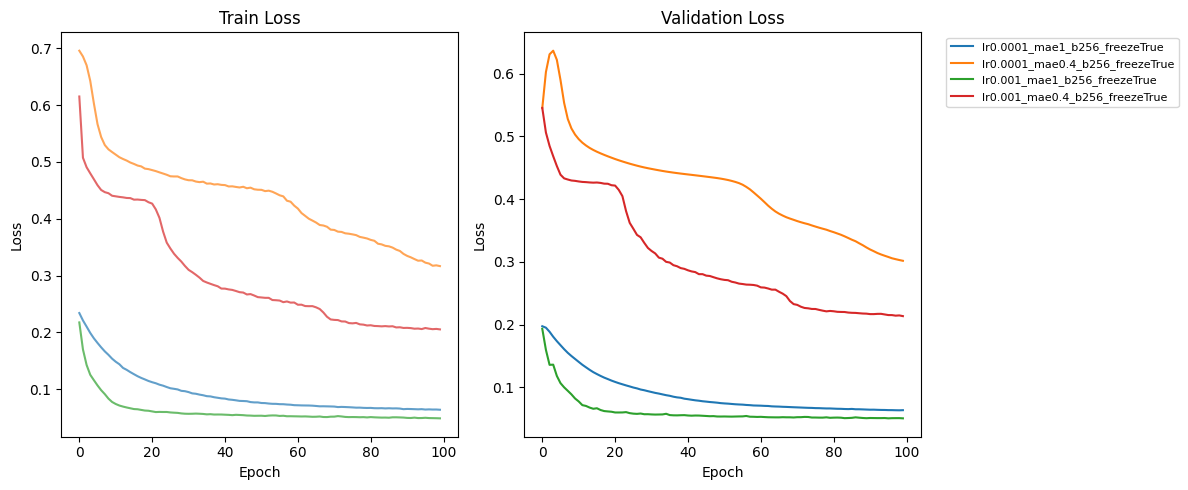

In [18]:
plt.figure(figsize=(12, 5))

# ---- TRAIN ----
plt.subplot(1, 2, 1)
for r in results:
    train_losses = r['losses']['train']
    plt.plot(train_losses, alpha=0.7)

plt.title("Train Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# ---- VAL ----
plt.subplot(1, 2, 2)
for r in results:
    val_losses = r['losses']['val']
    plt.plot(val_losses, label=r['name'])

plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Legend only for val
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

# 10. Best Model Selection + Evaluation

In [19]:
# Define weights for each metric
metric_weights = {
    'auc': 0.30,   # ROC-AUC
    'ap': 0.30,    # PR-AUC
    'recall': 0.15,    # catching anomalies is mor impt
    'f1': 0.10,        
    'precision': 0.10, 
    'accuracy': 0.05   # minor weight due to class imbalance
}

# Compute a weighted score for each result
for r in results:
    metrics = r['metrics']
    weighted_score = sum(metrics[k] * w for k, w in metric_weights.items())
    r['weighted_score'] = weighted_score
    print(f"{r['name']:<40} Weighted Score: {weighted_score:.4f}")

# Select best model based on weighted score
best = max(results, key=lambda x: x['weighted_score'])
print(f"\nBest config: {best['name']} (Weighted Score={best['weighted_score']:.4f})")

best_model = best['model']

lr0.0001_mae1_b256_freezeTrue            Weighted Score: 0.7301
lr0.0001_mae0.4_b256_freezeTrue          Weighted Score: 0.7275
lr0.001_mae1_b256_freezeTrue             Weighted Score: 0.7806
lr0.001_mae0.4_b256_freezeTrue           Weighted Score: 0.7646

Best config: lr0.001_mae1_b256_freezeTrue (Weighted Score=0.7806)


In [20]:
# Compute anomaly scores for test and val sets using the winning run's MAE/SSIM weight.
best_mae_weight = best.get('mae_weight_used', 0.4)
mae_scores, combined_scores, all_labels, val_combined = compute_scores(
    best_model,
    test_loader,
    val_loader,
    MAE_WEIGHT=best_mae_weight,
)

n_normal = int((all_labels == 0).sum())
n_anom   = int((all_labels == 1).sum())
print(f'\nTest set: {n_normal} normal, {n_anom} anomalous')
print(f'Best model MAE weight used for scoring: {best_mae_weight:.2f}')

best_model_name = best['name']
for tag, mae_s, comb_s in [(best_model_name, mae_scores, combined_scores)]:
    print(f'\nModel: [{tag}]')
    print(f'  MAE      — normal: {mae_s[all_labels==0].mean():.4f}, anom: {mae_s[all_labels==1].mean():.4f}')
    print(f'  Combined — normal: {comb_s[all_labels==0].mean():.4f}, anom: {comb_s[all_labels==1].mean():.4f}')

# Compute standard metrics using threshold from val set
threshold = val_combined.mean()
y_pred = (combined_scores > threshold).astype(int)

prec = precision_score(all_labels, y_pred)
rec  = recall_score(all_labels, y_pred)
f1   = f1_score(all_labels, y_pred)
acc  = accuracy_score(all_labels, y_pred)
bacc = balanced_accuracy_score(all_labels, y_pred)
roc  = roc_auc_score(all_labels, combined_scores)
ap   = average_precision_score(all_labels, combined_scores)

# Confusion matrix for FPR / FNR
tn, fp, fn, tp = confusion_matrix(all_labels, y_pred, labels=[0,1]).ravel()

fpr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

results_dict = {
    'auc': roc,
    'ap': ap,
    'f1': f1,
    'recall': rec,
    'precision': prec,
    'accuracy': acc,
    'bacc': bacc,
    'reference_threshold': threshold,
    'fpr': fpr,
    'fnr': fnr
}
metrics = [
    ('ROC-AUC', 'auc'),
    ('PR-AUC', 'ap'),
    ('F1', 'f1'),
    ('Recall', 'recall'),
    ('Precision', 'precision'),
    ('Accuracy', 'accuracy'),
    ('Balanced Acc','bacc'),
    ('Threshold', 'reference_threshold'),
    ('FPR', 'fpr'),
    ('FNR', 'fnr'),
]
print(f"\nMetrics (reference_threshold={threshold:.4f}):")
for name, key in metrics:
    print(f"  {name:<12}: {results_dict[key]:.4f}")

C:\Users\02eld\AppData\Roaming\Python\Python314\site-packages\torchmetrics\utilities\prints.py:69: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(



Test set: 58 normal, 92 anomalous
Best model MAE weight used for scoring: 1.00

Model: [lr0.001_mae1_b256_freezeTrue]
  MAE      — normal: 0.0486, anom: 0.0531
  Combined — normal: 0.0486, anom: 0.0531

Metrics (reference_threshold=0.0507):
  ROC-AUC     : 0.7749
  PR-AUC      : 0.8518
  F1          : 0.7394
  Recall      : 0.6630
  Precision   : 0.8356
  Accuracy    : 0.7133
  Balanced Acc: 0.7281
  Threshold   : 0.0507
  FPR         : 0.2069
  FNR         : 0.3370


In [21]:
# Sweep quantiles and select threshold
QUANTILES = np.linspace(0.2, 0.99, 50)
SELECTION_POLICY = 'fpr-constrained'
MAX_FPR = 0.20

auc = roc_auc_score(all_labels, combined_scores)
ap  = average_precision_score(all_labels, combined_scores)

sweep_rows = []
for q in QUANTILES:
    threshold = float(np.quantile(val_combined, q))
    preds = (combined_scores >= threshold).astype(int)
    prec = precision_score(all_labels, preds, zero_division=0)
    rec  = recall_score(all_labels, preds, zero_division=0)
    f1   = f1_score(all_labels, preds, zero_division=0)
    acc  = accuracy_score(all_labels, preds)
    bacc = balanced_accuracy_score(all_labels, preds)
    tn, fp, fn, tp = confusion_matrix(all_labels, preds, labels=[0,1]).ravel()
    fpr_at_thr = fp / (fp + tn) if (fp + tn) > 0 else float('nan')
    fnr        = fn / (fn + tp) if (fn + tp) > 0 else float('nan')

    sweep_rows.append({
        'q': q, 'threshold': threshold,
        'f1': f1, 'rec': rec, 'prec': prec,
        'acc': acc, 'bacc': bacc,
        'fpr': fpr_at_thr, 'fnr': fnr,
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    })

# Select best threshold
if SELECTION_POLICY == 'fpr-constrained':
    feasible = [r for r in sweep_rows if r['fpr'] <= MAX_FPR]
    if feasible:
        selected = max(feasible, key=lambda r: (r['rec'], r['f1'], -r['threshold']))
    else:
        selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))
else:
    selected = max(sweep_rows, key=lambda r: (r['f1'], r['rec'], -r['fpr']))

threshold = selected['threshold']

print(f'Selected threshold: {threshold:.6f} (quantile={selected["q"]:.2f})')
print(f'ROC-AUC: {auc:.4f}, PR-AUC: {ap:.4f}')
print(f'F1={selected["f1"]:.4f}, Recall={selected["rec"]:.4f}, Precision={selected["prec"]:.4f}')
print(f'Accuracy={selected["acc"]:.4f}, Balanced Acc={selected["bacc"]:.4f}')
print(f'FPR={selected["fpr"]:.4f}, FNR={selected["fnr"]:.4f}')
print(f'Confusion: TN={selected["tn"]}, FP={selected["fp"]}, FN={selected["fn"]}, TP={selected["tp"]}')

Selected threshold: 0.051398 (quantile=0.57)
ROC-AUC: 0.7749, PR-AUC: 0.8518
F1=0.7205, Recall=0.6304, Precision=0.8406
Accuracy=0.7000, Balanced Acc=0.7204
FPR=0.1897, FNR=0.3696
Confusion: TN=47, FP=11, FN=34, TP=58


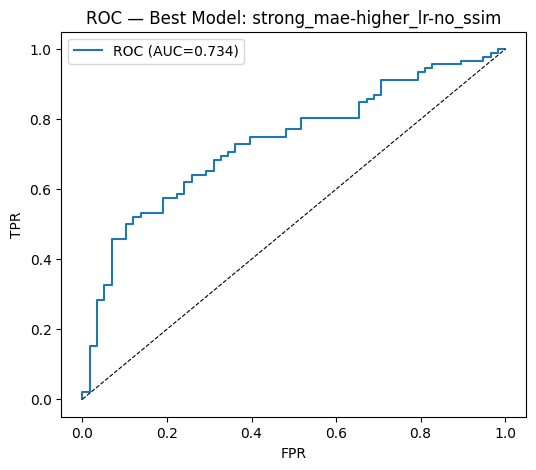

In [21]:
# Plot ROC curve
fpr_c, tpr_c, roc_thr = roc_curve(all_labels, combined_scores)
plot_idx = np.argmin(np.abs(roc_thr - threshold))

plt.figure(figsize=(6,5))
plt.plot(fpr_c, tpr_c, label=f'ROC (AUC={roc:.3f})')
# plt.scatter(fpr_c[plot_idx], tpr_c[plot_idx], color='red', zorder=5,
#             label=f'Selected thr ({threshold:.3f})')
plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title(f'ROC — Best Model: {best_model_name}')
plt.legend()
plt.show()


[lr0.001_mae1_b256_freezeTrue]  Pixel AUROC: 0.6949  Optimal threshold: 0.112341  Mean IoU: 0.0993  Std IoU: 0.0614


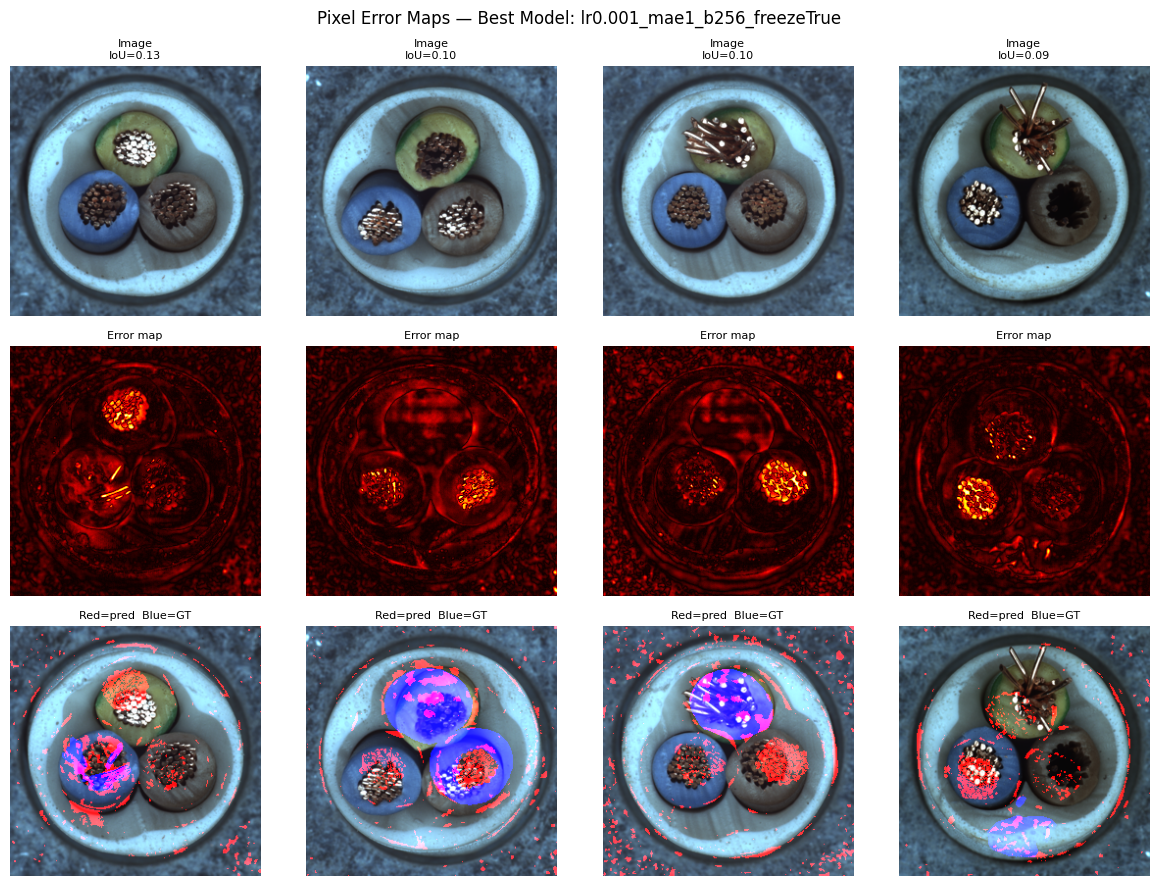

In [22]:
# Compute pixel-level maps
em_best, gt_best, iou_best, thr_best, px_auc = pixel_eval(best_model, best_model_name)

# Visualize a few images
n_vis = min(4, len(em_best))
vis_idx = np.linspace(0, len(em_best)-1, n_vis, dtype=int)

fig, axes = plt.subplots(3, n_vis, figsize=(3*n_vis, 9))
for col, vi in enumerate(vis_idx):
    orig = np.array(PILImage.open(test_loader.dataset.samples[vi][0]).convert('RGB').resize((256,256)))

    axes[0, col].imshow(orig)
    axes[0, col].set_title(f'Image\nIoU={iou_best[vi]:.2f}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(em_best[vi], cmap='hot')
    axes[1, col].set_title('Error map', fontsize=8)
    axes[1, col].axis('off')

    overlay = orig.copy()
    overlay[(em_best[vi] >= thr_best), 0] = 255  # Red = predicted anomaly
    overlay[gt_best[vi].astype(bool), 2] = 255   # Blue = ground truth
    axes[2, col].imshow(overlay)
    axes[2, col].set_title('Red=pred  Blue=GT', fontsize=8)
    axes[2, col].axis('off')

plt.suptitle(f'Pixel Error Maps — Best Model: {best_model_name}', fontsize=12)
plt.tight_layout()
plt.show()

In [23]:
# Summary table
print(f"{'Metric':<22} {'Value':>12}")
print('-'*35)
summary_metrics = [
    ('ROC-AUC', roc),
    ('PR-AUC', ap),
    ('F1', selected['f1']),
    ('Recall', selected['rec']),
    ('Precision', selected['prec']),
    ('Accuracy', selected['acc']),
    ('Balanced Acc', selected['bacc']),
    ('Threshold', selected['threshold']),
    ('FPR', selected['fpr']),
    ('FNR', selected['fnr']),
]
for label, value in summary_metrics:
    print(f'{label:<22} {value:>12.4f}')
print('-'*35)

Metric                        Value
-----------------------------------
ROC-AUC                      0.7749
PR-AUC                       0.8518
F1                           0.7205
Recall                       0.6304
Precision                    0.8406
Accuracy                     0.7000
Balanced Acc                 0.7204
Threshold                    0.0514
FPR                          0.1897
FNR                          0.3696
-----------------------------------


In [24]:
# Reference threshold metrics ---
ref_threshold = val_combined.mean()
y_pred_ref = (combined_scores > ref_threshold).astype(int)

prec_ref = precision_score(all_labels, y_pred_ref)
rec_ref  = recall_score(all_labels, y_pred_ref)
f1_ref   = f1_score(all_labels, y_pred_ref)
acc_ref  = accuracy_score(all_labels, y_pred_ref)
bacc_ref = balanced_accuracy_score(all_labels, y_pred_ref)
tn, fp, fn, tp = confusion_matrix(all_labels, y_pred_ref, labels=[0,1]).ravel()
fpr_ref = fp / (fp + tn)
fnr_ref = fn / (fn + tp)

# Optimized threshold metrics
opt_threshold = selected['threshold']
prec_opt = selected['prec']
rec_opt  = selected['rec']
f1_opt   = selected['f1']
acc_opt  = selected['acc']
bacc_opt = selected['bacc']
fpr_opt  = selected['fpr']
fnr_opt  = selected['fnr']

print(f"{'Metric':<22} {'Ref Thr.':>12} {'Optimized Thr.':>16}")
print('-'*52)

summary_metrics = [
    ('ROC-AUC', roc, roc),
    ('PR-AUC', ap, ap),
    ('F1', f1_ref, f1_opt),
    ('Recall', rec_ref, rec_opt),
    ('Precision', prec_ref, prec_opt),
    ('Accuracy', acc_ref, acc_opt),
    ('Balanced Acc', bacc_ref, bacc_opt),
    ('Threshold', ref_threshold, opt_threshold),
    ('FPR', fpr_ref, fpr_opt),
    ('FNR', fnr_ref, fnr_opt),
]

for label, ref_val, opt_val in summary_metrics:
    print(f"{label:<22} {ref_val:>12.4f} {opt_val:>16.4f}")

print('-'*52)

Metric                     Ref Thr.   Optimized Thr.
----------------------------------------------------
ROC-AUC                      0.7749           0.7749
PR-AUC                       0.8518           0.8518
F1                           0.7394           0.7205
Recall                       0.6630           0.6304
Precision                    0.8356           0.8406
Accuracy                     0.7133           0.7000
Balanced Acc                 0.7281           0.7204
Threshold                    0.0507           0.0514
FPR                          0.2069           0.1897
FNR                          0.3370           0.3696
----------------------------------------------------
